# 1D L2 Inversion with real data 

Workflow to do L2 inversion in real line data

In [31]:
# SimPEG functionality
import simpeg.electromagnetics.frequency_domain as fdem
from simpeg.utils import plot_1d_layer_model, download, mkvc
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)

# discretize functionality
from discretize import TensorMesh

# Common Python functionality
import os
import numpy as np
import pandas as pd
from scipy.constants import mu_0
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import ipywidgets
import dill
%matplotlib inline
mpl.rcParams.update({"font.size": 12})

#Import helper functions
import sys
import data_functions, inversion_functions


# Read the data:

Read from csv file of block 53:

In [33]:
# Get the current working directory (where the notebook is running)
current_dir = os.getcwd()

# Move one level up to the parent directory
parent_dir = os.path.dirname(current_dir)

# Construct the full path to the CSV file in the parent directory
csv_path = os.path.join(parent_dir, "block53_fdem_inv.csv")

fdem_data = pd.read_csv(csv_path) ## Set to the position of the csv_files list where the database you want is
pd.set_option('display.max_columns', len(fdem_data.columns))
fdem_data.head()

/var/folders/gb/v44v1_q914718nzwmm90d6pr0000gn/T/ipykernel_28684/3595362424.py:10: DtypeWarning: Columns (80,86,87,311,312) have mixed types. Specify dtype option on import or set low_memory=False.
  fdem_data = pd.read_csv(csv_path) ## Set to the position of the csv_files list where the database you want is


,x_tx,y_tx,gpsz_tx,altlas_bird,altlas_bird_derot,altrad_heli,bird_pitch,bird_roll,bird_yaw,Block,cp40k_reim,cp140k_reim,cp400_reim,cp1800_reim,cp8200_reim,cpi40k,cpi140k,cpi400,cpi1800,cpi8200,cpq40k,cpq140k,cpq400,cpq1800,cpq8200,cpsp,cx3300_reim,cxi3300,cxq3300,cxsp,date,ddep40k,ddep140k,ddep400,ddep1800,ddep8200,dep40k,dep140k,dep400,dep1800,dep8200,diurnal,diurnal_cor,dtm,fid,flight,gpsz_heli,igrf,lat_heli,lat_tx,Line,line(1),long_heli,long_tx,mag_diu,mag_lag,mag_rmi,mag_rmi analytic signal,mag_rmi hd filtered,mag_rmi rtp filtered,mag_rmi tilt angle,mag_rmi vd filtered,mag_rmi_HDX,mag_rmi_HDY,mag_tmi,powerline,res40k,res140k,res400,res1800,res8200,time_ssm,x_heli,y_heli,iter,beta,phi_d,phi_m,f,n_layers,resistivies,resistivity_hsp,phi_d_star,chi_factor,rms,doi_CA2012,Sj_star_CA2012,S_CA2012,rho01,rho02,rho03,rho04,rho05,rho06,rho07,rho08,rho09,rho10,rho11,rho12,rho13,rho14,rho15,rho16,rho17,rho18,rho19,rho20,rho21,rho22,rho23,rho24,rho25,rho26,rho27,rho28,rho29,rho30,rho31,rho32,rho33,rho34,rho35,rho36,rho37,rho38,rho39,rho40,thick01,thick02,thick03,thick04,thick05,thick06,thick07,thick08,thick09,thick10,thick11,thick12,thick13,thick14,thick15,thick16,thick17,thick18,thick19,thick20,thick21,thick22,thick23,thick24,thick25,thick26,thick27,thick28,thick29,thick30,thick31,thick32,thick33,thick34,thick35,thick36,thick37,thick38,thick39,dpred_cpi140k,dpred_cpq140k,dpred_cpi40k,dpred_cpq40k,dpred_cpi8200,dpred_cpq8200,dpred_cpi1800,dpred_cpq1800,dpred_cpi400,dpred_cpq400,dobs_cpi140k,dobs_cpq140k,dobs_cpi40k,dobs_cpq40k,dobs_cpi8200,dobs_cpq8200,dobs_cpi1800,dobs_cpq1800,dobs_cpi400,dobs_cpq400,rho_halfspace,rho01_mref1,rho02_mref1,rho03_mref1,rho04_mref1,rho05_mref1,rho06_mref1,rho07_mref1,rho08_mref1,rho09_mref1,rho10_mref1,rho11_mref1,rho12_mref1,rho13_mref1,rho14_mref1,rho15_mref1,rho16_mref1,rho17_mref1,rho18_mref1,rho19_mref1,rho20_mref1,rho21_mref1,rho22_mref1,rho23_mref1,rho24_mref1,rho25_mref1,rho26_mref1,rho27_mref1,rho28_mref1,rho29_mref1,rho30_mref1,rho31_mref1,rho32_mref1,rho33_mref1,rho34_mref1,rho35_mref1,rho36_mref1,rho37_mref1,rho38_mref1,rho39_mref1,rho40_mref1,rho_hsp_mref1,rho01_mref2,rho02_mref2,rho03_mref2,rho04_mref2,rho05_mref2,rho06_mref2,rho07_mref2,rho08_mref2,rho09_mref2,rho10_mref2,rho11_mref2,rho12_mref2,rho13_mref2,rho14_mref2,rho15_mref2,rho16_mref2,rho17_mref2,rho18_mref2,rho19_mref2,rho20_mref2,rho21_mref2,rho22_mref2,rho23_mref2,rho24_mref2,rho25_mref2,rho26_mref2,rho27_mref2,rho28_mref2,rho29_mref2,rho30_mref2,rho31_mref2,rho32_mref2,rho33_mref2,rho34_mref2,rho35_mref2,rho36_mref2,rho37_mref2,rho38_mref2,rho39_mref2,rho40_mref2,rho_hsp_mref2,doi_index_layer01,doi_index_layer02,doi_index_layer03,doi_index_layer04,doi_index_layer05,doi_index_layer06,doi_index_layer07,doi_index_layer08,doi_index_layer09,doi_index_layer10,doi_index_layer11,doi_index_layer12,doi_index_layer13,doi_index_layer14,doi_index_layer15,doi_index_layer16,doi_index_layer17,doi_index_layer18,doi_index_layer19,doi_index_layer20,doi_index_layer21,doi_index_layer22,doi_index_layer23,doi_index_layer24,doi_index_layer25,doi_index_layer26,doi_index_layer27,doi_index_layer28,doi_index_layer29,doi_index_layer30,doi_index_layer31,doi_index_layer32,doi_index_layer33,doi_index_layer34,doi_index_layer35,doi_index_layer36,doi_index_layer37,doi_index_layer38,doi_index_layer39,doi_index_layer40,dist,depths,alts,depth01,alt01,depth02,alt02,depth03,alt03,depth04,alt04,depth05,alt05,depth06,alt06,depth07,alt07,depth08,alt08,depth09,alt09,depth10,alt10,depth11,alt11,depth12,alt12,depth13,alt13,depth14,alt14,depth15,alt15,depth16,alt16,depth17,alt17,depth18,alt18,depth19,alt19,depth20,alt20,depth21,alt21,depth22,alt22,depth23,alt23,depth24,alt24,depth25,alt25,depth26,alt26,depth27,alt27,depth28,alt28,depth29,alt29,depth30,alt30,depth31,alt31,depth32,alt32,depth33,alt33,depth34,alt34,depth35,alt35,depth36,alt36,depth37,alt37,depth38,alt38,depth39,alt39,depth40,alt40,depth41,alt41,doi_OL1999,doi_alt_OL1999,doi_alt_CA2012,x,y,z,layer,rho
0,553008.70

In [34]:
# Set Halfspace conductivity:
conductivities_hsp = 0.024795715924493058
resistivities_hsp = 1/conductivities_hsp

# Inversion Process

Of a single Line:

In [36]:
# Define like working with:
line_no = 'L530100'
line = fdem_data.loc[fdem_data['Line'] == line_no].copy()

# Calculate the tx_rx coordinates:
line = data_functions.calculate_tx_rx_coordinates(line)

# Get fid values
line_stations = line.fid.values

print(line_stations)

[   nan    nan    nan ... 2490.7 2490.8 2490.9]


In [37]:
#Define the single fid from line
fid_n = 2457.0

line_station = line.loc[line.fid == fid_n].iloc[0]

## Calculate the height 

#Calculate the height (terrain clearance)
line_station.loc['height_tx'] = line_station['gpsz_tx'] - line_station['dtm']

## Defining the Survey

Same for all soundings: 
RESOLVE 6 system flew by by Xcalibur Multiphysic in August 2024. Nominal frequencies 135 kHz, 40 kHz, 8.2 kHz, 1.8 kHz and 400 

### Generate source and receivers locations

In [40]:
freq_avoid = []
survey = inversion_functions.survey_object(line_station, freq_avoid)

## Defining Data Object


In [42]:
# Defines the data object and assigns uncertainties with the noise floor
uncertainty_floor = 5.0e0
relative_error = 0.05 #What is relative error?

data_object = inversion_functions.data_object(line_station, relative_error = relative_error, noise_floor = uncertainty_floor, survey = survey, freq_avoid = freq_avoid)

# Halfspace Inversion

In [44]:
### Mesh Definition for l2 inversion ###

### Depth max ###
min_frequency = 400
skin_depth = 503*np.sqrt(resistivities_hsp/np.min(min_frequency))
depth_max = 2*skin_depth  # depth to lowest layer

### Mesh Definition ###

regularization_mesh_L2, log_conductivity_L2_map, simulation_L2, n_layers = inversion_functions.mapping_forward_objects(n_layers = 2, survey = survey, depth_max = depth_max, depth_min = 1, geometric_factor = 1.3)


In [72]:
# Starting model is log-conductivity values (S/m) from halfspace results
starting_conductivity_model_L2 = np.log(conductivities_hsp * np.ones(n_layers))

# Reference model is also log-resistivity values (S/m)
reference_conductivity_model_L2 = starting_conductivity_model.copy()


## Data Misfit 

In [75]:
dmis_hsp_L2 = data_misfit.L2DataMisfit(simulation=simulation_L2, data=data_object)

## Regularization

In [78]:
reg_L2 = inversion_functions.regularization_object(regularization_mesh_L2, reference_conductivity_model = reference_conductivity_model_L2 , alpha_s = 1e-5, alpha_x = 1)

## Optimization

In [81]:
opt_L2 = optimization.InexactGaussNewton(
    maxIter=100, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

## Inversion Parameters

In [84]:
# Combine the inverse problem and the set of directives
inv_L2 = inversion_functions.inversion_setup(dmis_hsp_L2, reg_L2, opt_L2, beta_ratio = 1e1)

## Running Inversion

In [93]:
#%%capture 
#To not show output
recovered_model_L2 = inv_L2.run(starting_conductivity_model_L2)

## Get the recovered halfspace resistivity from model estimated
conductivities_L2 = log_conductivity_L2_map * recovered_halfspace_model_L2
resistivities_L2 = 1 / conductivities_L2


Running inversion with SimPEG v0.23.1.dev1+g60e0c3a5

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation1DLayered problem***
                        
model has any nan: 0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  2.21e+02  1.13e+02  9.99e-32  1.13e+02    1.46e+02      0              


/opt/anaconda3/lib/python3.12/site-packages/simpeg/simulation.py:197: DefaultSolverWarning: Using the default solver: SolverLU. 

If you would like to suppress this notification, add 
warnings.filterwarnings('ignore', simpeg.utils.solver_utils.DefaultSolverWarning)
 to your script.
  return get_default_solver(warn=True)
/opt/anaconda3/lib/python3.12/site-packages/pymatsolver/wrappers.py:81: SparseEfficiencyWarning: splu converted its input to CSC format
  self.solver = fun(self.A, **self.kwargs)


   1  2.21e+02  2.32e+01  2.62e-02  2.90e+01    3.60e+01      0              
   2  1.48e+02  1.87e+01  2.43e-02  2.23e+01    8.89e+00      0              
   3  1.48e+02  1.58e+01  4.03e-02  2.17e+01    7.37e-01      0              
   4  9.84e+01  1.58e+01  4.02e-02  1.97e+01    7.99e+00      0              
   5  9.84e+01  1.28e+01  6.54e-02  1.92e+01    9.36e-01      0              
   6  6.56e+01  1.27e+01  6.57e-02  1.70e+01    7.17e+00      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 0.0000e+00 <= tolF*(1+|f0|) = 1.1424e+01
1 : |xc-x_last| = 4.2562e-01 <= tolX*(1+|x0|) = 1.7115e+00
0 : |proj(x-g)-x|    = 7.1701e+00 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.1701e+00 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =     100    <= iter          =      7
------------------------- DONE! -------------------------


## Plot results

In [110]:
frequencies

array([135000.,  40000.,   8200.,   3300.,   1800.,    400.])

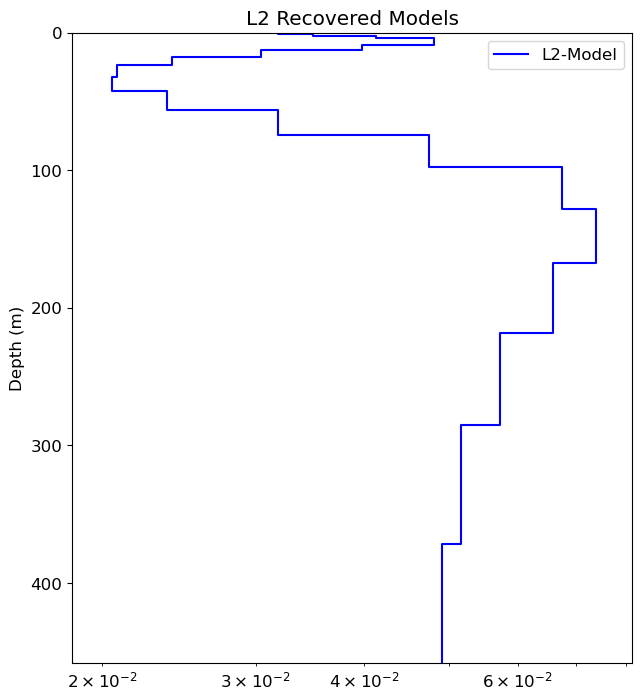

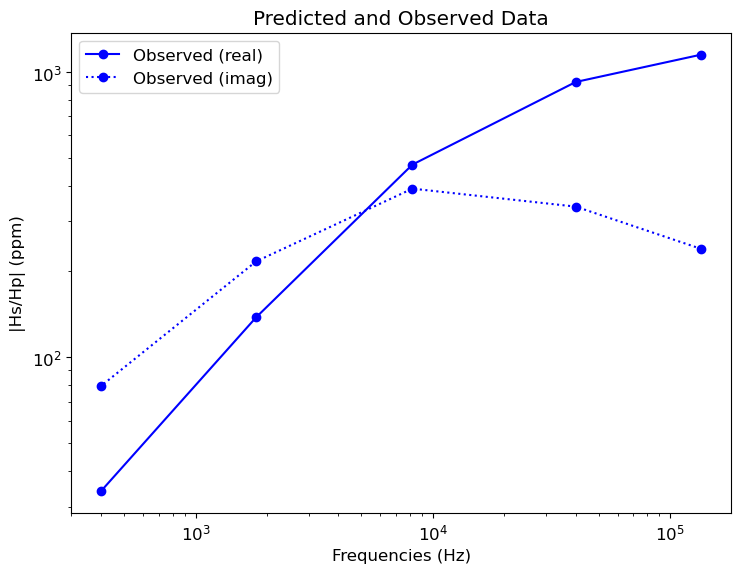

In [118]:
frequencies = np.r_[135, 40, 8.2, 1.8, 0.4]*1e3

fig = plt.figure(figsize=(8, 9))


ax1 = fig.add_axes([0.2, 0.15, 0.7, 0.7])

plot_1d_layer_model(
    regularization_mesh_L2.h[0], log_conductivity_L2_map  * recovered_model_L2, ax=ax1, show_layers=False, color="b"#, plot_elevation = True
)

#ax1.set_xlim(0.01, 10)
ax1.set_title("L2 Recovered Models")
ax1.legend(["L2-Model", "Sparse Model"])
#plt.gca().invert_yaxis()

# Plot predicted and observed data
dpred_l2 = simulation_L2.dpred(recovered_model_L2)

fig = plt.figure(figsize=(11, 6))
ax1 = fig.add_axes([0.2, 0.1, 0.6, 0.8])
#ax1.loglog(frequencies, np.abs(dobs[0::2]), "k-o")
#ax1.loglog(frequencies, np.abs(dobs[1::2]), "k:o")
ax1.loglog(frequencies, np.abs(dpred_l2[0::2]), "b-o")
ax1.loglog(frequencies, np.abs(dpred_l2[1::2]), "b:o")
ax1.set_xlabel("Frequencies (Hz)")
ax1.set_ylabel("|Hs/Hp| (ppm)")
ax1.set_title("Predicted and Observed Data")
ax1.legend(
    [
        "Observed (real)",
        "Observed (imag)",
        "L2-Model (real)",
        "L2-Model (imag)",
        "Sparse (real)",
        "Sparse (imag)",
    ],
    loc="upper left",
)
plt.show()

In [29]:
#> /dev/null

# ToDos
* Use paralelizations and GPUs